# Hydrogen marginal abatement cost curve

Compare each hydrogen technology with NG-SMR using direct stack-emissions abatement. The cost numerator annualizes CAPEX and includes operating costs and CCS transport and storage, while excluding product revenue and carbon payments. These routes are alternatives at the same annual output, so their chart widths are not additive. Results display inline by default; saving CSV and PNG files is optional.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_macc import (
    DEFAULT_MACC_TECHNOLOGIES,
    deterministic_hydrogen_macc,
    generate_hydrogen_macc_outputs,
    plot_hydrogen_macc,
    simulated_hydrogen_macc,
)
from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
)

pd.options.display.float_format = "{:,.3f}".format

## Settings

Deterministic mode uses expected inputs. Simulated mode uses aligned Monte Carlo draws; its headline cost is mean incremental annual cost divided by mean annual abatement, while p05/median/p95 summarize draw-level cost. Sampled retrofit BAU mode shares the NG-SMR parent draw between the reference and NG-SMR + CCS.

In [2]:
USE_SIMULATED = False
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = DEFAULT_MACC_TECHNOLOGIES
SAVE_OUTPUTS = False

mode_label = "simulated" if USE_SIMULATED else "deterministic"
print(f"Selected MACC mode: {mode_label}")
print(f"Technologies: {', '.join(TECHNOLOGIES)}")
if USE_SIMULATED:
    print(f"Monte Carlo draws: {SAMPLE_SIZE:,}")
    print(f"Random seed: {RANDOM_SEED}")
    print(f"Retrofit BAU mode: {RETROFIT_BAU_MODE}")

Selected MACC mode: deterministic
Technologies: ael, pem, soec, methane_pyrolysis_tcd, biomass_gasification, biomethane_smr, ng_smr_ccs


## Calculate MACC values

In [3]:
if USE_SIMULATED:
    macc = simulated_hydrogen_macc(
        sample_size=SAMPLE_SIZE,
        random_seed=RANDOM_SEED,
        technologies=TECHNOLOGIES,
        retrofit_bau_mode=RETROFIT_BAU_MODE,
    )
else:
    macc = deterministic_hydrogen_macc(technologies=TECHNOLOGIES)

display(macc)

,technology,label,annual_abatement_tco2,annual_abatement_mtco2,abatement_share_of_reference,incremental_annual_cost_eur,abatement_cost_eur_per_tco2,abatement_cost_p05_eur_per_tco2,abatement_cost_median_eur_per_tco2,abatement_cost_p95_eur_per_tco2
0,biomass_gasification,Biomass gasification,"900,000.000",0.900,1.000,"25,207,136.258",28.008,28.008,28.008,28.008
1,ng_smr_ccs,NG-SMR + CCS,"810,000.000",0.810,0.900,"59,999,902.740",74.074,74.074,74.074,74.074
2,biomethane_smr,Biomethane SMR,"900,000.000",0.900,1.000,"211,549,800.000",235.055,235.055,235.055,235.055
3,methane_pyrolysis_tcd,Methane pyrolysis (TCD),"900,000.000",0.900,1.000,"230,957,148.589",256.619,256.619,256.619,256.619
4,soec,SOEC,"900,000.000",0.900,1.000,"377,601,320.100",419.557,419.557,419.557,419.557
5,ael,AEL,"900,000.000",0.900,1.000,"504,156,517.140",560.174,560.174,560.174,560.174
6,pem,PEM,"900,000.000",0.900,1.000,"533,565,454.587",592.851,592.851,592.851,592.851


## Plot MACC

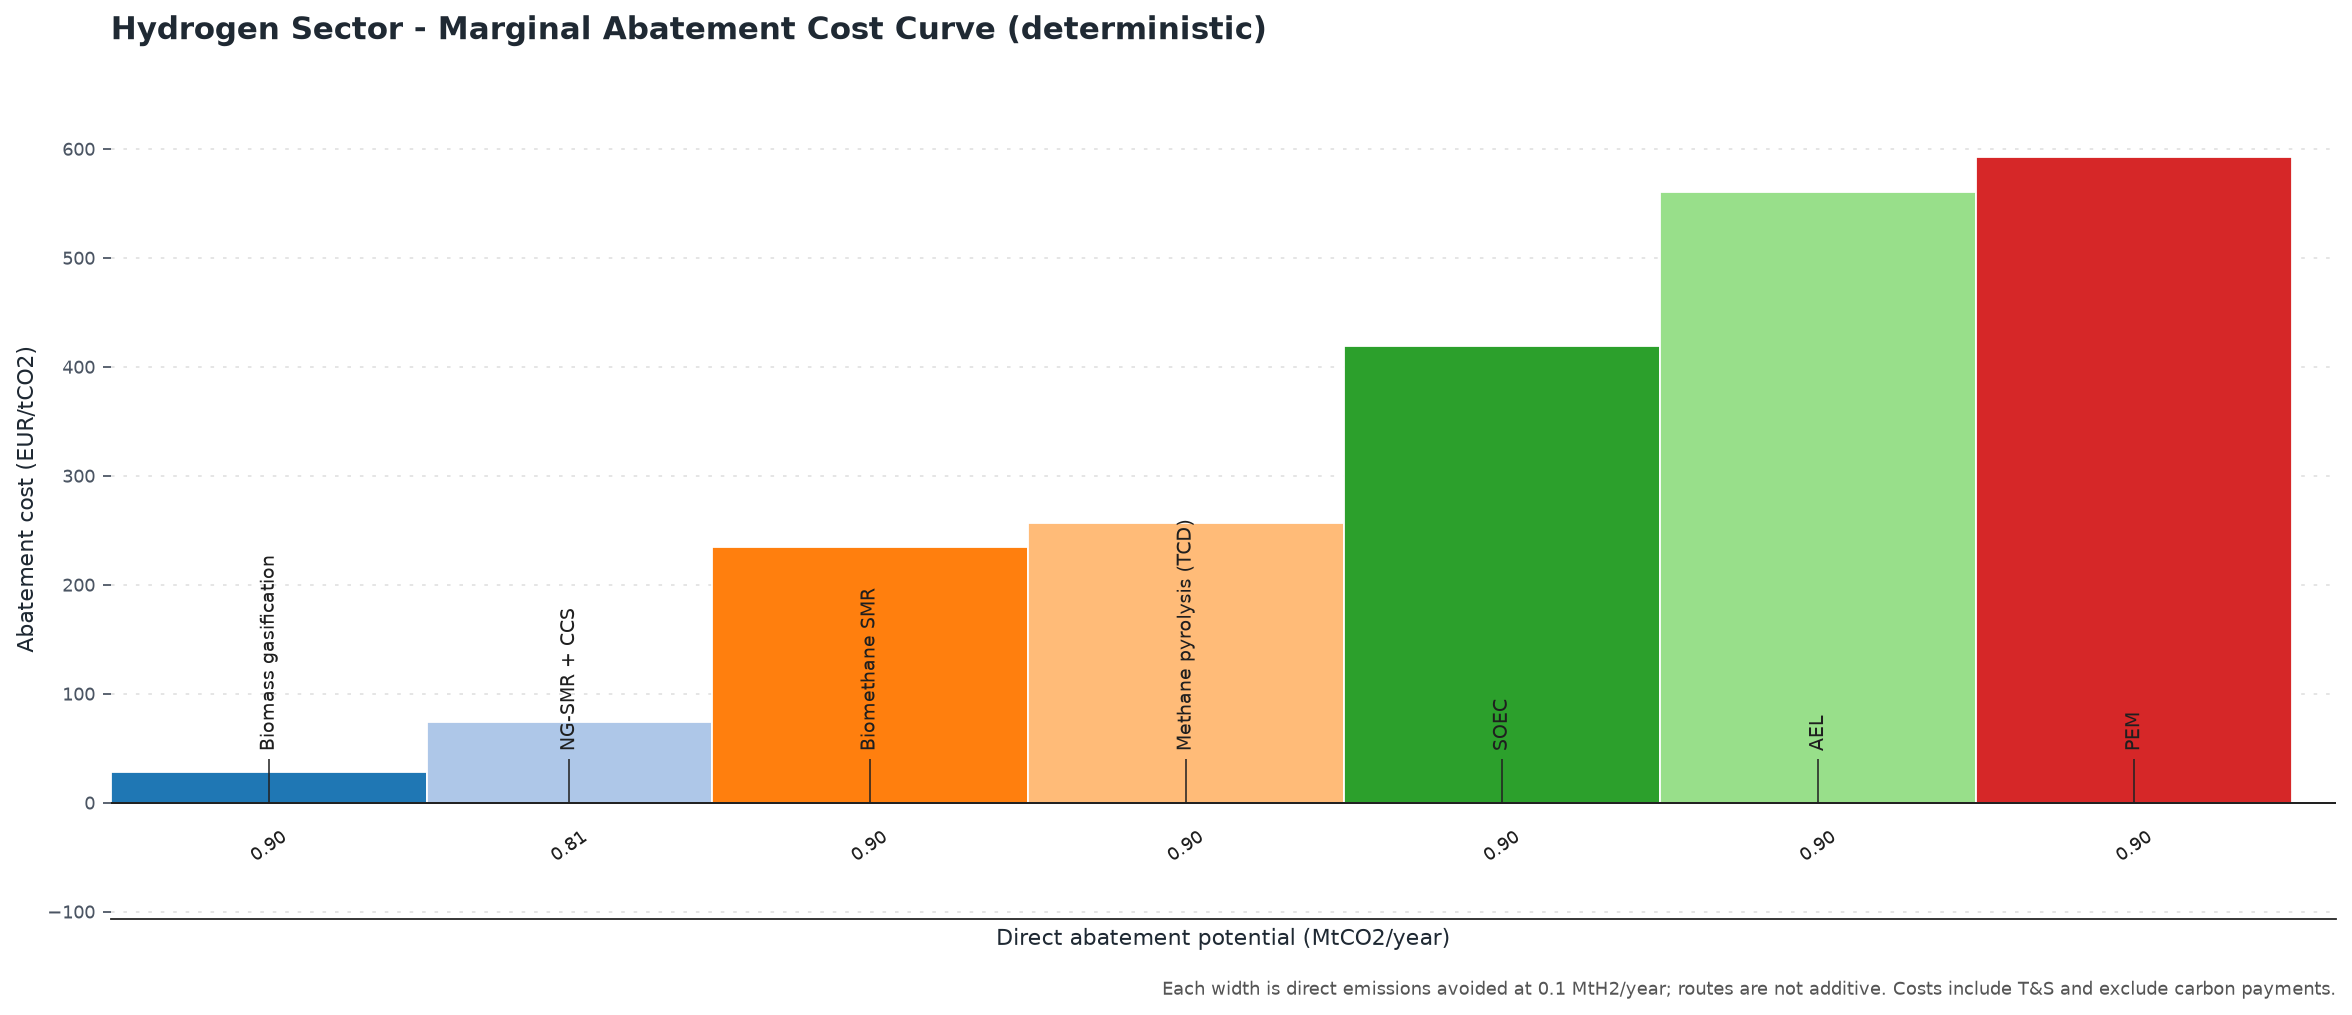

In [4]:
fig = plot_hydrogen_macc(
    macc,
    title=f"Hydrogen Sector - Marginal Abatement Cost Curve ({mode_label})",
)
plt.show()
plt.close(fig)

## Optional output files

Set `SAVE_OUTPUTS = True` in the settings cell to write one CSV to `data/processed/` and one PNG to `figures/`.

In [5]:
if SAVE_OUTPUTS:
    saved_paths = generate_hydrogen_macc_outputs(
        project_root=PROJECT_ROOT,
        deterministic=not USE_SIMULATED,
        sample_size=SAMPLE_SIZE,
        random_seed=RANDOM_SEED,
        technologies=TECHNOLOGIES,
        retrofit_bau_mode=RETROFIT_BAU_MODE,
    )
    for path in saved_paths:
        print(path.relative_to(PROJECT_ROOT))
else:
    print("SAVE_OUTPUTS is False; no files were written.")

SAVE_OUTPUTS is False; no files were written.
